<a href="https://colab.research.google.com/github/myoohit/IIT-Madras-assignment/blob/main/ImagingScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

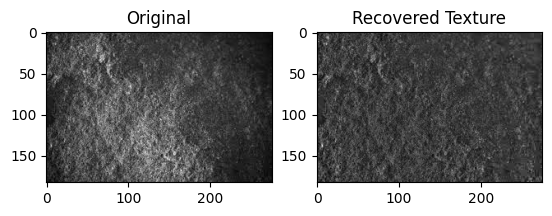

In [11]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


img = cv2.imread('surface.jpeg', cv2.IMREAD_GRAYSCALE)
img = img.astype(float) + 1


log_img = np.log(img)


def box_filter(im, ksize):
    pad = ksize // 2
    padded = np.pad(im, pad, mode='edge')
    filtered = np.zeros_like(im)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            box = padded[i:i+ksize, j:j+ksize]
            filtered[i,j] = np.mean(box)
    return filtered

ksize = 31
low_freq = box_filter(log_img, ksize)


log_reflectance = log_img - low_freq
reflectance = np.exp(log_reflectance)


reflectance = (reflectance / np.max(reflectance) * 255).astype(np.uint8)
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(122), plt.imshow(reflectance, cmap='gray'), plt.title('Recovered Texture')
plt.show()


In [6]:
img = cv2.imread('surface.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image not loaded. Check filename and upload the file.")


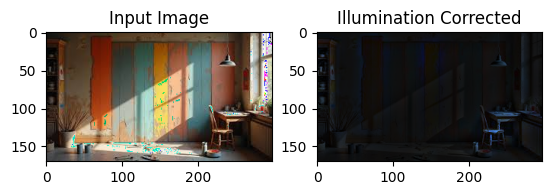

In [10]:
color_img = cv2.imread('surface_colorr.jpeg')
color_img = color_img.astype(float) + 1

recovered = np.zeros_like(color_img)
ksize = 31

for c in range(3):
    log_img_c = np.log(color_img[:,:,c])
    low_freq_c = box_filter(log_img_c, ksize)
    log_reflectance_c = log_img_c - low_freq_c
    reflectance_c = np.exp(log_reflectance_c)
    recovered[:,:,c] = reflectance_c


max_pixel = np.max(recovered)
recovered = (recovered / max_pixel * 255).astype(np.uint8)


plt.subplot(121), plt.imshow(cv2.cvtColor(color_img.astype(np.uint8), cv2.COLOR_BGR2RGB)), plt.title('Input Image')
plt.subplot(122), plt.imshow(cv2.cvtColor(recovered, cv2.COLOR_BGR2RGB)), plt.title('Illumination Corrected')
plt.show()
